In [1]:
# Load Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load dataset
data = pd.read_csv("ibm_hr_employee-attrition.csv")
print("Dataset loaded successfully.")
data.info()

Dataset loaded successfully.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 


In [3]:
# Identify numerical and categorical columns
num_columns = data.select_dtypes(include=['number']).columns
cat_columns = data.select_dtypes(exclude=['number']).columns
print(f"\nNumerical columns ({len(num_columns)}): {list(num_columns)}")
print(f"Categorical columns ({len(cat_columns)}): {list(cat_columns)}")


Numerical columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']



Enter the name of a numerical column: Age
Statistics for Age:

Mean: 36.923809523809524
Median: 36.0
Mode: 35
Standard Deviation: 9.135373489136734
Variance: 83.45504878602227
Range: 42



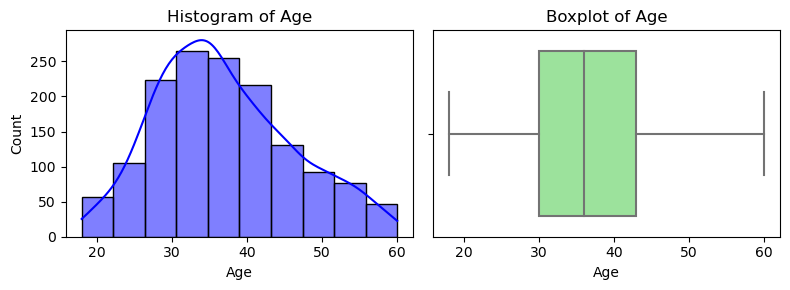

Outliers in Age: 0
Series([], Name: Age, dtype: int64)


In [8]:
# Numerical column analysis
num_column = input("\nEnter the name of a numerical column: ")
if num_column in data.columns:
    column_data = data[num_column]
    mean = column_data.mean()
    median = column_data.median()
    mode = column_data.mode().iloc[0] if not column_data.mode().empty else None
    std_dev = column_data.std()
    variance = column_data.var()
    value_range = column_data.max() - column_data.min()
    
    print(f"Statistics for {num_column}:\n")
    print(f"Mean: {mean}")
    print(f"Median: {median}")
    print(f"Mode: {mode}")
    print(f"Standard Deviation: {std_dev}")
    print(f"Variance: {variance}")
    print(f"Range: {value_range}\n")

    # Generate histogram and boxplot
    plt.figure(figsize=(8, 3))
    
    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(column_data, kde=True, bins=10, color='blue')
    plt.title(f"Histogram of {num_column}")

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=column_data, color='lightgreen')
    plt.title(f"Boxplot of {num_column}")

    plt.tight_layout()
    plt.show()
    
    q1 = column_data.quantile(0.25)
    q3 = column_data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)

    outliers = column_data[(column_data < lower_bound) | (column_data > upper_bound)]
    
    print(f"Outliers in {num_column}: {len(outliers)}")
    print(outliers)

else:
    print(f"Column '{num_column}' not found in the dataset.")



Enter the name of a categorical column: Attrition
Choose chart type (bar/pie): bar


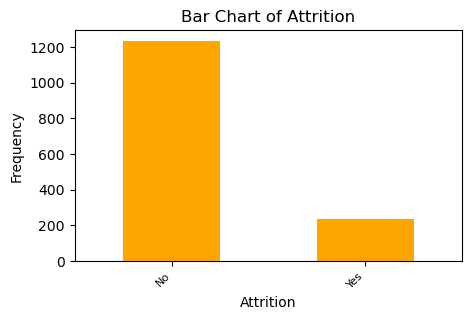

Frequency of categories in Attrition:
No     1233
Yes     237
Name: Attrition, dtype: int64



In [9]:

# Categorical column analysis
cat_column = input("\nEnter the name of a categorical column: ")
if cat_column in data.columns:
    category_counts = data[cat_column].value_counts()
    chart_type = input("Choose chart type (bar/pie): ")
    if chart_type == 'bar':
        category_counts.plot(kind='bar', color='orange', figsize=(5, 3))
        plt.title(f"Bar Chart of {cat_column}")
        plt.xlabel(cat_column)
        plt.ylabel("Frequency")
        plt.xticks(fontsize=8)
        plt.xticks(rotation=45,ha='right')
        plt.show()
    elif chart_type == 'pie':
        category_counts.plot(kind='pie', autopct="%.1f%%", figsize=(4, 4), colormap='tab10')
        plt.title(f"Pie Chart of {cat_column}")
        plt.ylabel("")
        plt.show()
    else:
        print("Invalid chart type. Please use 'bar' or 'pie'.")
    print(f"Frequency of categories in {cat_column}:\n{category_counts}\n")
else:
        print(f"Column '{cat_column}' not found in the dataset.")